# VAYU — Data Preparation Pipeline
## Step 4: Classification Dataset

**Prerequisite:** Run `vayu_step2_cleaning.ipynb` first.

---

### What This Step Builds

**Models that will use this data:** Logistic Regression, KNN, SVM, Decision Trees, Random Forest *(Lectures 18–24, 31–36, 56–60)*

**Target variable:** `AQI_category` — 6 classes: Good, Satisfactory, Moderate, Poor, Very Poor, Severe  
**Features:** PM2.5, PM10, NO2, SO2, CO, O3 + time features + city (encoded)

### How Classification Differs from Regression

| Requirement | Regression | Classification |
|---|---|---|
| Target type | Numeric (float) | Integer label (0–5) |
| Scaling needed? | No for trees | Yes for KNN and SVM |
| Class balance? | Not applicable | Critical |
| Stratified split | By city | By AQI_category |
| City encoding | Not needed | Label-encoded integer |

### Steps in This Notebook
1. Load master cleaned file
2. Compute/standardize AQI_category (target)
3. Check class imbalance
4. Select and encode features
5. Train/test split stratified by AQI_category
6. Apply SMOTE oversampling to train set if needed
7. Scale features (two versions)
8. Feature importance preview
9. Save classification datasets

In [ ]:
import os
import json
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi']        = 120
plt.rcParams['font.family']       = 'DejaVu Sans'
plt.rcParams['axes.spines.top']   = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titlesize']    = 13
plt.rcParams['axes.labelsize']    = 11
sns.set_palette('muted')

pd.set_option('display.max_columns', 40)

OUTPUT_DIR = './data/cleaned/02_classification'
SHARED_DIR = './data/cleaned/04_shared'
os.makedirs(OUTPUT_DIR, exist_ok=True)

CAT_ORDER  = ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
CAT_COLORS = {
    'Good'        : '#00E400',
    'Satisfactory': '#92D050',
    'Moderate'    : '#FFFF00',
    'Poor'        : '#FF7E00',
    'Very Poor'   : '#FF0000',
    'Severe'      : '#99004C',
}
CAT_TO_INT = {cat: i for i, cat in enumerate(CAT_ORDER)}
INT_TO_CAT = {i: cat for cat, i in CAT_TO_INT.items()}

print('Setup complete.')

Setup complete.


---
## Section 1 — Load Master Cleaned File

In [35]:
parquet_path = os.path.join(SHARED_DIR, 'master_cleaned.parquet')
csv_path     = os.path.join(SHARED_DIR, 'master_cleaned.csv')

if os.path.exists(parquet_path):
    df = pd.read_parquet(parquet_path)
    print(f'Loaded from parquet: {parquet_path}')
else:
    df = pd.read_csv(csv_path, low_memory=False)
    print(f'Loaded from CSV: {csv_path}')

print(f'Shape : {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Columns: {list(df.columns)}')

Loaded from CSV: ./data/cleaned/05_shared/master_cleaned.csv
Shape : 842,160 rows x 35 columns
Columns: ['city', 'state', 'latitude', 'longitude', 'datetime', 'month', 'day_name', 'is_weekend', 'season', 'time_of_day', 'humidity_percent', 'dew_point_c', 'wind_gusts_kmh', 'precipitation_mm', 'is_raining', 'heavy_rain', 'pressure_msl_hpa', 'cloud_cover_percent', 'pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'dust_ugm3', 'aod', 'us_aqi', 'aqi_category', 'pm25_category_india', 'festival_period', 'crop_burning_season', 'year', 'day', 'hour', 'day_of_week']


In [36]:
# Auto-detect columns
POLLUTANT_KEYWORDS = ['pm2', 'pm10', 'no2', 'so2', 'co_', 'o3', 'ozone', 'nh3']
EXCLUDE_KEYWORDS   = ['cloud', 'cover', 'humidity', 'temp', 'pressure',
                      'wind', 'rain', 'solar', 'visibility', 'dew', 'uv']

pollutant_cols = [
    c for c in df.select_dtypes(include=[np.number]).columns
    if any(k in c.lower() for k in POLLUTANT_KEYWORDS)
    and not any(ex in c.lower() for ex in EXCLUDE_KEYWORDS)
]
city_col = next((c for c in df.columns if c.lower() in ['city', 'city_name']), None)
date_col = next((c for c in df.columns
                 if 'datetime' in c.lower() or c.lower() == 'date'), None)
cat_col  = next((c for c in df.columns
                 if 'category' in c.lower() or 'bucket' in c.lower()), None)
aqi_col  = next((c for c in df.columns
                 if c.lower() in ['aqi', 'air_quality_index']), None)

print(f'Pollutant cols : {pollutant_cols}')
print(f'City col       : {city_col}')
print(f'Date col       : {date_col}')
print(f'Category col   : {cat_col}')
print(f'AQI col        : {aqi_col}')

Pollutant cols : ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3']
City col       : city
Date col       : datetime
Category col   : aqi_category
AQI col        : None


---
## Section 2 — Build AQI_category (Target Variable)

### The Target for Classification

The target is one of 6 CPCB category labels encoded as integers 0–5:

| Integer | Category | AQI Range |
|---|---|---|
| 0 | Good | 0–50 |
| 1 | Satisfactory | 51–100 |
| 2 | Moderate | 101–200 |
| 3 | Poor | 201–300 |
| 4 | Very Poor | 301–400 |
| 5 | Severe | 401–500 |

In [ ]:
def aqi_to_category(val):
    if pd.isna(val) or val < 0: return np.nan
    if val <= 50:               return 'Good'
    if val <= 100:              return 'Satisfactory'
    if val <= 200:              return 'Moderate'
    if val <= 300:              return 'Poor'
    if val <= 400:              return 'Very Poor'
    return 'Severe'

# ── Step 1: Get or derive AQI_category string column ──────────────────────
if cat_col and cat_col in df.columns:
    # Show raw unique values so we can see exactly what needs mapping
    raw_unique = df[cat_col].dropna().unique()
    print(f'Raw unique values in "{cat_col}":')
    print(f'  {sorted([str(v) for v in raw_unique])}')

    # Build a flexible standardization map that handles any casing/spacing
    def standardize_cat(val):
        if pd.isna(val): return np.nan
        s = str(val).strip().lower().replace('  ', ' ')
        mapping = {
            'good'        : 'Good',
            'satisfactory': 'Satisfactory',
            'moderate'    : 'Moderate',
            'poor'        : 'Poor',
            'very poor'   : 'Very Poor',
            'severe'      : 'Severe',
        }
        return mapping.get(s, np.nan)   # unmapped values → NaN, never silently kept

    df['AQI_category'] = df[cat_col].apply(standardize_cat)
    mapped   = df['AQI_category'].notna().sum()
    unmapped = df['AQI_category'].isna().sum()
    print(f'\nMapped successfully : {mapped:,}')
    print(f'Unmapped (NaN)     : {unmapped:,}')
    if unmapped > 0:
        # Show what values failed to map
        failed = df.loc[df['AQI_category'].isna(), cat_col].dropna().unique()
        print(f'Values that failed to map: {failed[:10]}')

elif aqi_col and aqi_col in df.columns:
    df['AQI_category'] = pd.to_numeric(df[aqi_col], errors='coerce').apply(aqi_to_category)
    print(f'Derived AQI_category from numeric "{aqi_col}"')
else:
    # Derive from PM2.5 sub-index as last resort
    pm25_col = next((c for c in pollutant_cols
                     if 'pm2' in c.lower() and 'pm10' not in c.lower()), None)
    if pm25_col:
        def pm25_subindex(v):
            if pd.isna(v): return np.nan
            for lo, hi, ilo, ihi in [(0,30,0,50),(30,60,51,100),(60,90,101,200),
                                      (90,120,201,300),(120,250,301,400),(250,500,401,500)]:
                if lo <= v <= hi:
                    return ((ihi-ilo)/(hi-lo))*(v-lo)+ilo
            return 500
        df['AQI_category'] = df[pm25_col].apply(pm25_subindex).apply(aqi_to_category)
        print(f'Derived AQI_category from PM2.5 sub-index')
    else:
        raise ValueError('Cannot build AQI_category - no category, AQI, or PM2.5 column found.')

print(f'\nAQI_category value counts:')
print(df['AQI_category'].value_counts().to_string())
print(f'NaN count: {df["AQI_category"].isna().sum():,}')

Raw unique values in "aqi_category":
  ['Good', 'Moderate']

Mapped successfully : 522,309
Unmapped (NaN)     : 319,851
Values that failed to map: <StringArray>
[]
Length: 0, dtype: str

AQI_category value counts:
AQI_category
Moderate    385833
Good        136476
NaN count: 319,851


In [38]:
# ── Step 2: Drop rows with NaN category, then encode to integer ────────────
before = len(df)
df     = df[df['AQI_category'].isin(CAT_ORDER)].copy().reset_index(drop=True)
print(f'Rows kept with valid category : {len(df):,}')
print(f'Rows dropped (NaN category)   : {before - len(df):,}')

if len(df) == 0:
    raise ValueError(
        'ERROR: 0 rows remain after filtering for valid AQI_category.\n'
        'This means the category column values do not match the expected labels.\n'
        'Check the raw unique values printed in the cell above.'
    )

df['AQI_label'] = df['AQI_category'].map(CAT_TO_INT)
print('\nLabel encoding confirmed:')
for cat, n in df['AQI_category'].value_counts().reindex(CAT_ORDER).dropna().items():
    print(f'  {CAT_TO_INT[cat]} -> {cat:<15}  {n:,} rows')

Rows kept with valid category : 522,309
Rows dropped (NaN category)   : 319,851

Label encoding confirmed:
  0 -> Good             136,476.0 rows
  2 -> Moderate         385,833.0 rows


---
## Section 3 — Class Imbalance Analysis

### Why Class Imbalance Destroys Classification Models

If 70% of data is "Moderate" and only 1% is "Severe", a classifier reaches **70% accuracy by always predicting Moderate** — without ever learning Severe. For AQI specifically, Severe days are the most important to predict correctly — they trigger health advisories.

**Imbalance ratio** = largest class / smallest class
- < 3x → no action needed  
- 3–10x → use `class_weight='balanced'`  
- > 10x → use SMOTE *(Lectures 39–41)*

Class distribution:
  Good            136,476.0  ( 26.1%)  #############
  Moderate        385,833.0  ( 73.9%)  ####################################

Imbalance ratio : 2.8x
Strategy        : None needed (balanced enough)


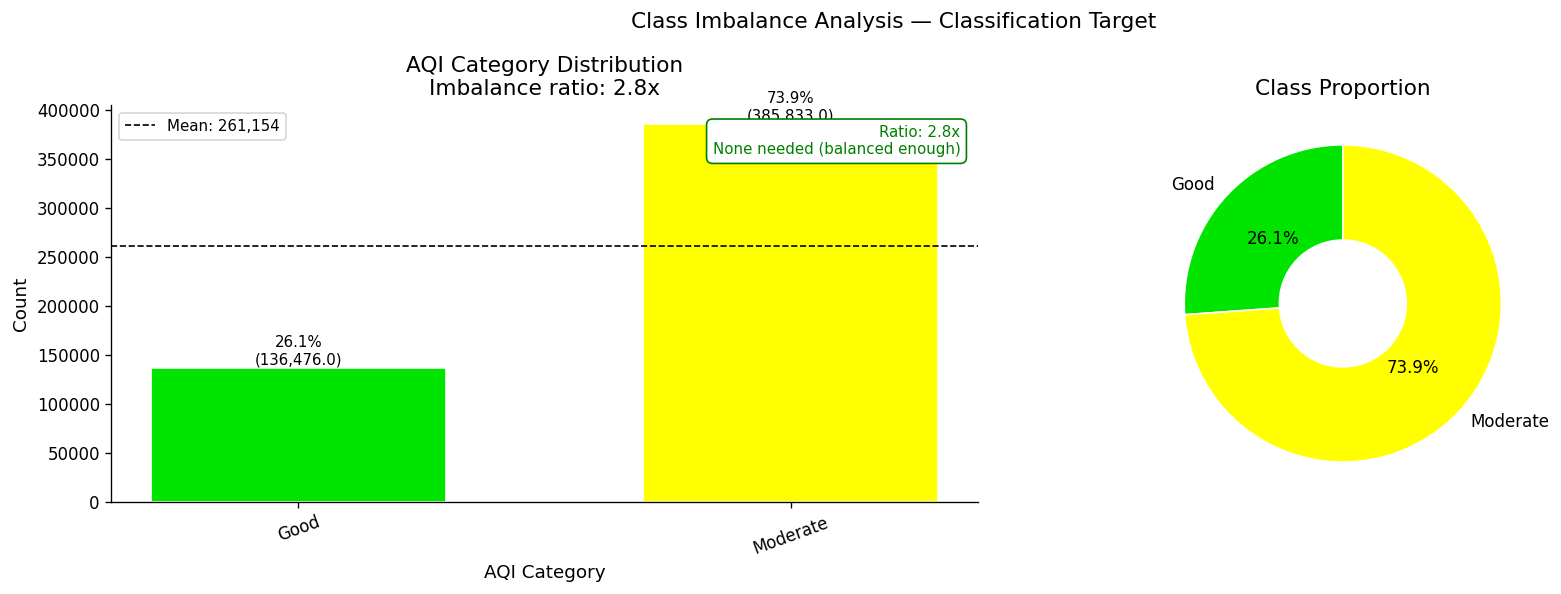

In [ ]:
counts    = df['AQI_category'].value_counts().reindex(CAT_ORDER).dropna()
pcts      = (counts / counts.sum() * 100).round(2)
clrs      = [CAT_COLORS[c] for c in counts.index]
imb_ratio = counts.max() / counts.min()

print('Class distribution:')
for cat, cnt, pct in zip(counts.index, counts.values, pcts.values):
    bar = '#' * int(pct / 2)
    print(f'  {cat:<15} {cnt:>8,}  ({pct:>5.1f}%)  {bar}')
print(f'\nImbalance ratio : {imb_ratio:.1f}x')

if   imb_ratio > 10: strategy = 'SMOTE (severe imbalance)'
elif imb_ratio > 3:  strategy = 'class_weight="balanced" (moderate imbalance)'
else:                strategy = 'None needed (balanced enough)'
print(f'Strategy        : {strategy}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

bars = axes[0].bar(counts.index, counts.values, color=clrs, edgecolor='white', width=0.6)
axes[0].axhline(counts.mean(), color='black', linestyle='--', linewidth=1,
                label=f'Mean: {counts.mean():,.0f}')
for bar, pct, val in zip(bars, pcts.values, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + counts.max() * 0.01,
                 f'{pct:.1f}%\n({val:,})', ha='center', fontsize=9)
axes[0].set_title(f'AQI Category Distribution\nImbalance ratio: {imb_ratio:.1f}x')
axes[0].set_xlabel('AQI Category')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(fontsize=9)
warn_color = 'red' if imb_ratio > 10 else 'orange' if imb_ratio > 3 else 'green'
axes[0].text(0.98, 0.95, f'Ratio: {imb_ratio:.1f}x\n{strategy}',
             ha='right', va='top', transform=axes[0].transAxes, fontsize=9,
             color=warn_color,
             bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor=warn_color))

axes[1].pie(counts.values, labels=counts.index, colors=clrs,
            autopct='%1.1f%%', startangle=90,
            wedgeprops=dict(width=0.6, edgecolor='white'))
axes[1].set_title('Class Proportion')

plt.suptitle('Class Imbalance Analysis - Classification Target', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 4 — Feature Selection + Encoding

### Why Include City for Classification But Not Regression?

City encodes geographic and industrial context. Delhi and Patna are in "Very Poor" far more often than Bengaluru — this geographic signal is not captured by pollutant readings alone on a given day.

We **label-encode** city (each city → unique integer) rather than one-hot encode (which would create 29 dummy columns).

In [ ]:
df_work = df.copy()

# Encode season (only if the column exists AND has actual values)
season_map = {'Winter': 0, 'Spring': 1, 'Summer': 2, 'Monsoon': 3}
if 'season' in df_work.columns and df_work['season'].notna().any():
    df_work['season_enc'] = df_work['season'].map(season_map)
    print('season_enc created from season column')
else:
    print('No season column found - season_enc skipped')

# Encode city (text -> integer)
city_encoding_map = {}
if city_col and city_col in df_work.columns:
    le_city = LabelEncoder()
    df_work['city_enc'] = le_city.fit_transform(df_work[city_col].astype(str))
    city_encoding_map   = dict(zip(le_city.classes_,
                                   le_city.transform(le_city.classes_).tolist()))
    print('City encoding (first 10):')
    for city, code in list(sorted(city_encoding_map.items(), key=lambda x: x[1]))[:10]:
        print(f'  {code:>3} -> {city}')
    if len(city_encoding_map) > 10:
        print(f'  ... and {len(city_encoding_map)-10} more cities')

# Build feature list
TIME_FEATURES = ['month', 'hour', 'day_of_week']
time_feats    = [f for f in TIME_FEATURES if f in df_work.columns]
if 'season_enc' in df_work.columns:  time_feats.append('season_enc')

ALL_FEATURES  = pollutant_cols.copy()
if 'city_enc' in df_work.columns:    ALL_FEATURES.append('city_enc')
ALL_FEATURES += time_feats

TARGET_STR = 'AQI_category'
TARGET_INT = 'AQI_label'

# ── Remove any feature that is ALL NaN before running dropna ────────────────
# A single all-NaN feature wipes every row when dropna runs
all_nan_features = []
for feat in ALL_FEATURES:
    if feat in df_work.columns and df_work[feat].isna().all():
        all_nan_features.append(feat)

if all_nan_features:
    print(f'\nRemoving all-NaN features (would delete every row): {all_nan_features}')
    ALL_FEATURES = [f for f in ALL_FEATURES if f not in all_nan_features]

# Only keep features that actually exist
ALL_FEATURES = [f for f in ALL_FEATURES if f in df_work.columns]

print(f'\nFinal features ({len(ALL_FEATURES)}): {ALL_FEATURES}')

# NaN counts for remaining features
print('\nNaN count per feature (before dropping):')
for feat in ALL_FEATURES:
    n    = df_work[feat].isna().sum()
    flag = '  <- will drop rows' if n > 0 else ''
    print(f'  {feat:<35} {n:>8,}{flag}')

# Drop rows with NaN in any remaining feature or target
keep_cols = ALL_FEATURES + [TARGET_STR, TARGET_INT]
before    = len(df_work)
df_clf    = df_work[[c for c in keep_cols if c in df_work.columns]].dropna().reset_index(drop=True)
dropped   = before - len(df_clf)

print(f'\nRows before dropping NaN : {before:,}')
print(f'Rows after  dropping NaN : {len(df_clf):,}  (dropped {dropped:,})')

if len(df_clf) == 0:
    raise ValueError(
        'ERROR: 0 rows remain after dropna.\n'
        'Check the NaN counts above for any feature still showing large NaN counts.'
    )

print(f'\nFinal class distribution:')
print(df_clf[TARGET_STR].value_counts().reindex(CAT_ORDER).dropna().to_string())

season_enc created from season column
City encoding (first 10):
    0 -> agartala
    1 -> ahmedabad
    2 -> aizawl
    3 -> bengaluru
    4 -> bhopal
    5 -> bhubaneswar
    6 -> chandigarh
    7 -> chennai
    8 -> dehradun
    9 -> delhi
  ... and 19 more cities

Removing all-NaN features (would delete every row): ['season_enc']

Final features (10): ['pm2_5_ugm3', 'pm10_ugm3', 'co_ugm3', 'no2_ugm3', 'so2_ugm3', 'o3_ugm3', 'city_enc', 'month', 'hour', 'day_of_week']

NaN count per feature (before dropping):
  pm2_5_ugm3                                 0
  pm10_ugm3                                  0
  co_ugm3                                    0
  no2_ugm3                                   0
  so2_ugm3                                   0
  o3_ugm3                                    0
  city_enc                                   0
  month                                      0
  hour                                       0
  day_of_week                                0

Rows before

---
## Section 5 — Train/Test Split

We split **before** SMOTE. The test set must always reflect the real-world class distribution — applying SMOTE before splitting would contaminate the test set with synthetic samples, making evaluation unrealistically optimistic.

In [41]:
X = df_clf[ALL_FEATURES].values
y = df_clf[TARGET_INT].values

print(f'X shape : {X.shape}')
print(f'y shape : {y.shape}')
print(f'Classes : {np.unique(y)}')
print(f'Class counts: {dict(zip(*np.unique(y, return_counts=True)))}')

# Check for any class with < 2 samples (would break stratify)
unique, counts_arr = np.unique(y, return_counts=True)
tiny_classes = [(INT_TO_CAT[u], c) for u, c in zip(unique, counts_arr) if c < 2]
if tiny_classes:
    print(f'\nWARNING: Classes with < 2 samples (cannot stratify): {tiny_classes}')
    print('Removing these rows...')
    valid_mask = np.isin(y, [u for u, c in zip(unique, counts_arr) if c >= 2])
    X, y       = X[valid_mask], y[valid_mask]
    print(f'Rows after removal: {len(y):,}')

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y
)

print(f'\nTrain : {len(X_train):,} rows  ({len(X_train)/len(X)*100:.1f}%)')
print(f'Test  : {len(X_test):,}  rows  ({len(X_test)/len(X)*100:.1f}%)')

print('\nTrain class distribution (before balancing):')
for label, count in sorted(zip(*np.unique(y_train, return_counts=True))):
    pct = count / len(y_train) * 100
    print(f'  {label} ({INT_TO_CAT[label]:<15}) : {count:>8,}  ({pct:.1f}%)')

X shape : (522309, 10)
y shape : (522309,)
Classes : [0 2]
Class counts: {np.int64(0): np.int64(136476), np.int64(2): np.int64(385833)}

Train : 417,847 rows  (80.0%)
Test  : 104,462  rows  (20.0%)

Train class distribution (before balancing):
  0 (Good           ) :  109,181  (26.1%)
  2 (Moderate       ) :  308,666  (73.9%)


---
## Section 6 — Handle Class Imbalance with SMOTE

### SMOTE — Synthetic Minority Over-sampling Technique *(Lectures 39–41)*

SMOTE does not copy minority rows — it creates **new synthetic samples** along the line between existing minority-class neighbors. This avoids overfitting on the minority class while still increasing its representation.

Applied **only to training set**. Test set is never modified.

Imbalance ratio 2.8x < 3x — SMOTE not needed.


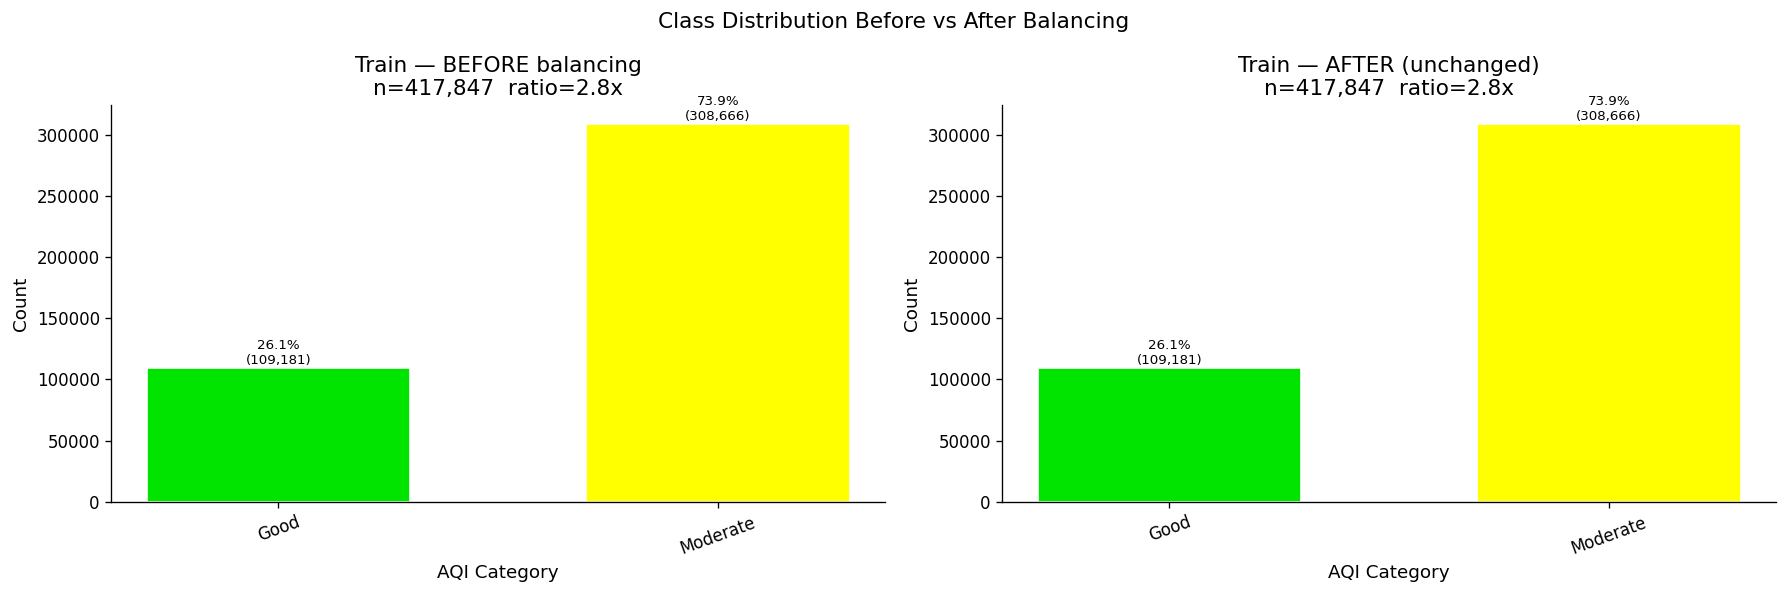

In [ ]:
smote_applied = False
X_train_bal   = X_train.copy()
y_train_bal   = y_train.copy()

if imb_ratio > 3:
    try:
        from imblearn.over_sampling import SMOTE

        # k_neighbors must be < the count of the smallest class in train
        min_train_count = min(np.unique(y_train, return_counts=True)[1])
        k = min(5, min_train_count - 1)

        print(f'Applying SMOTE (k_neighbors={k}) to training set only...')
        sm = SMOTE(random_state=42, k_neighbors=k)
        X_train_bal, y_train_bal = sm.fit_resample(X_train, y_train)
        smote_applied = True

        print(f'Train rows: {len(X_train):,} -> {len(X_train_bal):,}')
        print('After SMOTE class distribution:')
        for label, count in sorted(zip(*np.unique(y_train_bal, return_counts=True))):
            pct = count / len(y_train_bal) * 100
            print(f'  {label} ({INT_TO_CAT[label]:<15}) : {count:>8,}  ({pct:.1f}%)')

    except ImportError:
        print('imbalanced-learn not installed - SMOTE skipped.')
        print('Install: pip install imbalanced-learn')
        print('Fallback - add this to your classifiers when training:')
        print('  LogisticRegression(class_weight="balanced")')
        print('  RandomForestClassifier(class_weight="balanced")')
        print('  SVC(class_weight="balanced")')
else:
    print(f'Imbalance ratio {imb_ratio:.1f}x < 3x - SMOTE not needed.')

# ── Before / After chart ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

for ax, y_data, title in [
    (axes[0], y_train,     'Train - BEFORE balancing'),
    (axes[1], y_train_bal, f'Train - AFTER {"SMOTE" if smote_applied else "(unchanged)"}')
]:
    uniq, cnts = np.unique(y_data, return_counts=True)
    cats   = [INT_TO_CAT.get(u, str(u)) for u in uniq]
    clrs_b = [CAT_COLORS.get(c, '#888') for c in cats]
    bars   = ax.bar(cats, cnts, color=clrs_b, edgecolor='white', width=0.6)
    for bar, val in zip(bars, cnts):
        pct = val / cnts.sum() * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + cnts.max() * 0.01,
                f'{pct:.1f}%\n({val:,})', ha='center', fontsize=8)
    r = cnts.max() / cnts.min()
    ax.set_title(f'{title}\nn={len(y_data):,}  ratio={r:.1f}x')
    ax.set_xlabel('AQI Category')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=20)

plt.suptitle('Class Distribution Before vs After Balancing', fontsize=13)
plt.tight_layout()
plt.show()

---
## Section 7 — Feature Scaling

### Which Models Need Scaling?

| Model | Needs Scaling? | Why |
|---|---|---|
| Logistic Regression | Yes | Gradient descent converges faster |
| KNN | Yes | Distance-based — PM2.5 (0–1000) dominates hour (0–23) without scaling |
| SVM | Yes | Kernel is distance-based |
| Decision Trees | No | Uses thresholds not distances |
| Random Forest | No | Ensemble of trees |

**Critical:** Fit scaler on training set only — then transform test with same fitted scaler. Fitting on combined data = data leakage *(Lectures 42–45)*.

We save **two versions**: scaled (for KNN/SVM/LogReg) and unscaled (for Trees/RF).

Scaler fitted on training set.
Mean and std per feature (should be ~0 and ~1 after scaling):
  pm2_5_ugm3                          raw_mean=    19.070  raw_std=    10.781
  pm10_ugm3                           raw_mean=    29.424  raw_std=    19.752
  co_ugm3                             raw_mean=   306.701  raw_std=   175.092
  no2_ugm3                            raw_mean=     9.970  raw_std=    10.830
  so2_ugm3                            raw_mean=     7.030  raw_std=    10.083
  o3_ugm3                             raw_mean=    71.303  raw_std=    35.492
  city_enc                            raw_mean=    13.926  raw_std=     8.587
  month                               raw_mean=     7.073  raw_std=     2.980
  hour                                raw_mean=    11.246  raw_std=     6.908
  day_of_week                         raw_mean=     3.005  raw_std=     1.999

Scaled train means (all should be ~0): [-0. -0.  0. -0.  0. -0. -0. -0.  0.  0.]
Scaled train stds  (all should be ~1): [1. 1.

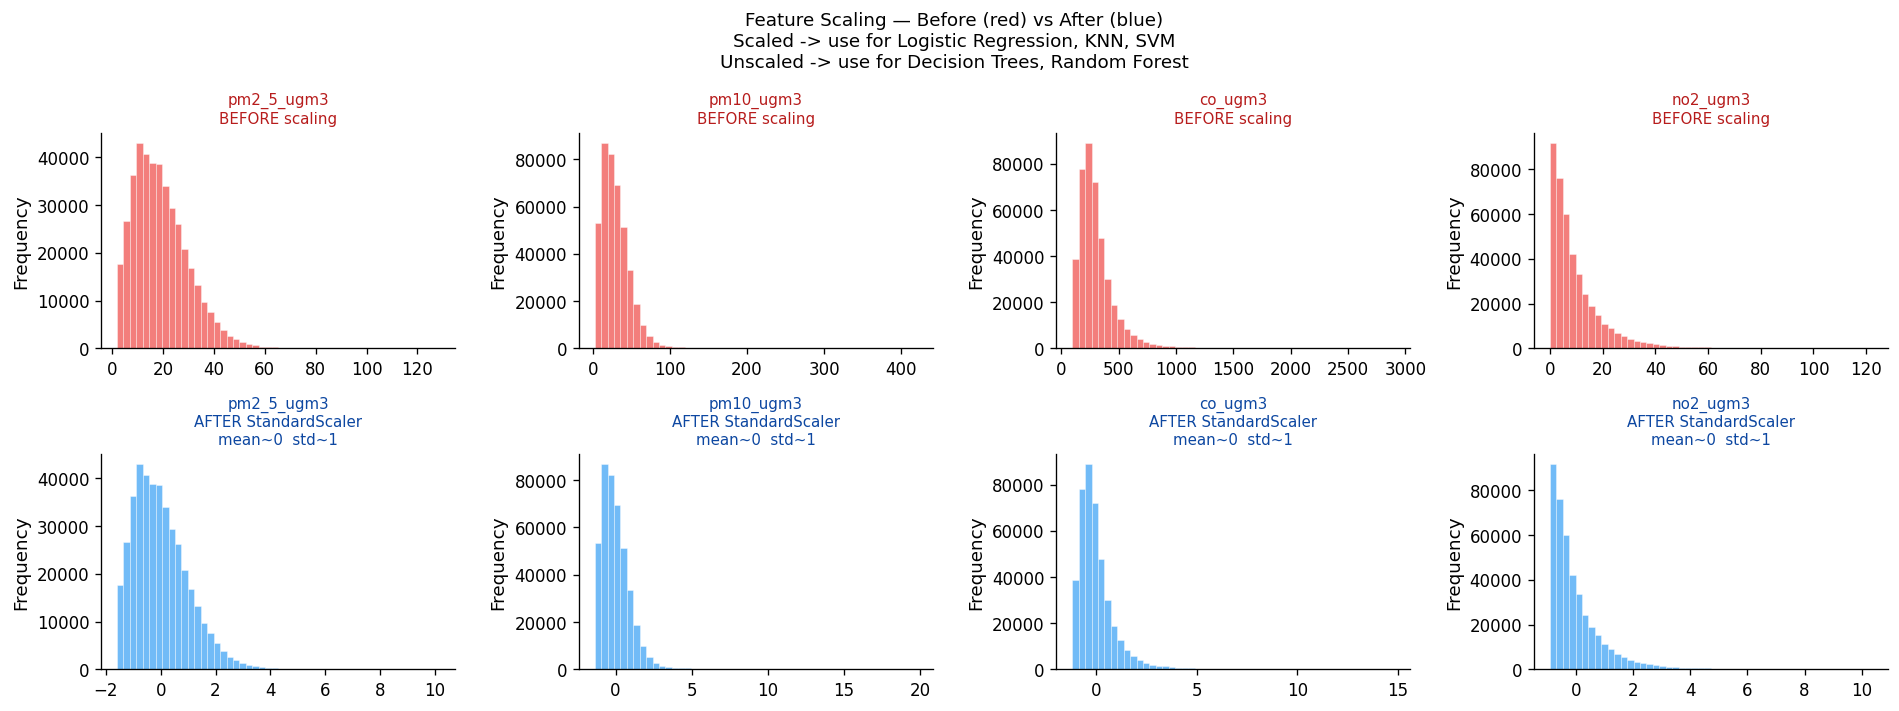

In [ ]:
# Fit on training set only
scaler          = StandardScaler()
X_train_scaled  = scaler.fit_transform(X_train_bal)
X_test_scaled   = scaler.transform(X_test)

print('Scaler fitted on training set.')
print('Mean and std per feature (should be ~0 and ~1 after scaling):')
for feat, mean, std in zip(ALL_FEATURES, scaler.mean_, scaler.scale_):
    print(f'  {feat:<35} raw_mean={mean:>10.3f}  raw_std={std:>10.3f}')

# Quick sanity check on scaled output
scaled_means = X_train_scaled.mean(axis=0)
scaled_stds  = X_train_scaled.std(axis=0)
print(f'\nScaled train means (all should be ~0): {scaled_means.round(4)}')
print(f'Scaled train stds  (all should be ~1): {scaled_stds.round(4)}')

# ── Before/After distributions ─────────────────────────────────────────────
n_show = min(4, len(ALL_FEATURES))
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 6), squeeze=False)

for i in range(n_show):
    feat = ALL_FEATURES[i]
    axes[0][i].hist(X_train_bal[:, i], bins=50, color='#EF5350',
                    alpha=0.75, edgecolor='white', linewidth=0.3)
    axes[0][i].set_title(f'{feat}\nBEFORE scaling', fontsize=9, color='#B71C1C')
    axes[0][i].set_ylabel('Frequency')

    axes[1][i].hist(X_train_scaled[:, i], bins=50, color='#42A5F5',
                    alpha=0.75, edgecolor='white', linewidth=0.3)
    axes[1][i].set_title(f'{feat}\nAFTER StandardScaler\nmean~0  std~1',
                          fontsize=9, color='#0D47A1')
    axes[1][i].set_ylabel('Frequency')

plt.suptitle('Feature Scaling - Before (red) vs After (blue)\n'
             'Scaled -> use for Logistic Regression, KNN, SVM\n'
             'Unscaled -> use for Decision Trees, Random Forest',
             fontsize=11)
plt.tight_layout()
plt.show()

---
## Section 8 — Split Verification + Feature Importance Preview

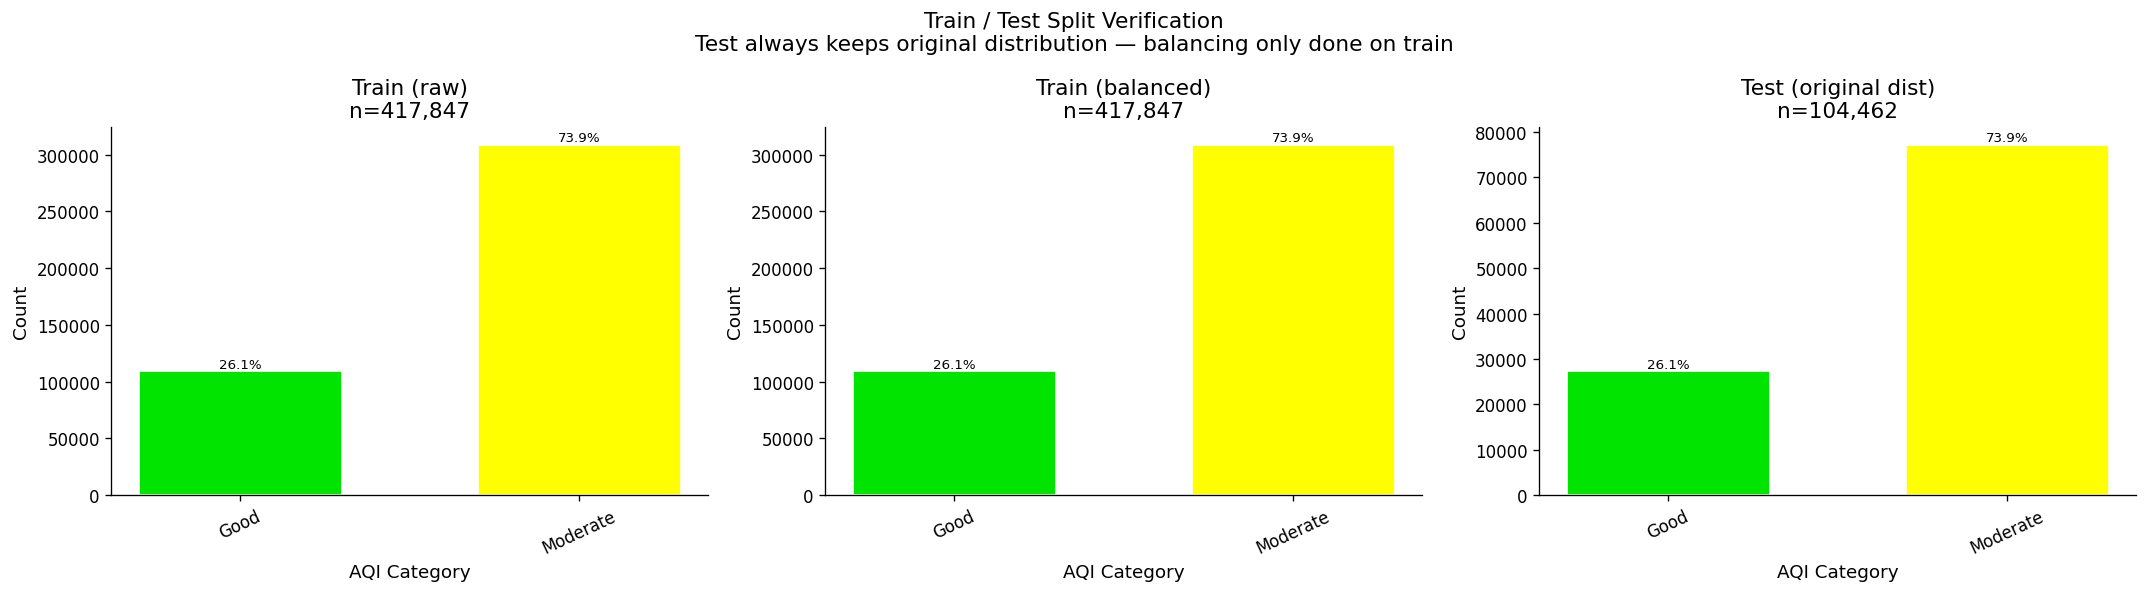

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, y_data, title in [
    (axes[0], y_train,     f'Train (raw)\nn={len(y_train):,}'),
    (axes[1], y_train_bal, f'Train (balanced)\nn={len(y_train_bal):,}'),
    (axes[2], y_test,      f'Test (original dist)\nn={len(y_test):,}'),
]:
    uniq, cnts = np.unique(y_data, return_counts=True)
    cats   = [INT_TO_CAT.get(u, str(u)) for u in uniq]
    clrs_b = [CAT_COLORS.get(c, '#888') for c in cats]
    bars   = ax.bar(cats, cnts, color=clrs_b, edgecolor='white', width=0.6)
    for bar, val in zip(bars, cnts):
        pct = val / cnts.sum() * 100
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + cnts.max() * 0.01,
                f'{pct:.1f}%', ha='center', fontsize=8)
    ax.set_title(title)
    ax.set_xlabel('AQI Category')
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=25)

plt.suptitle('Train / Test Split Verification\n'
             'Test always keeps original distribution - balancing only done on train',
             fontsize=13)
plt.tight_layout()
plt.show()

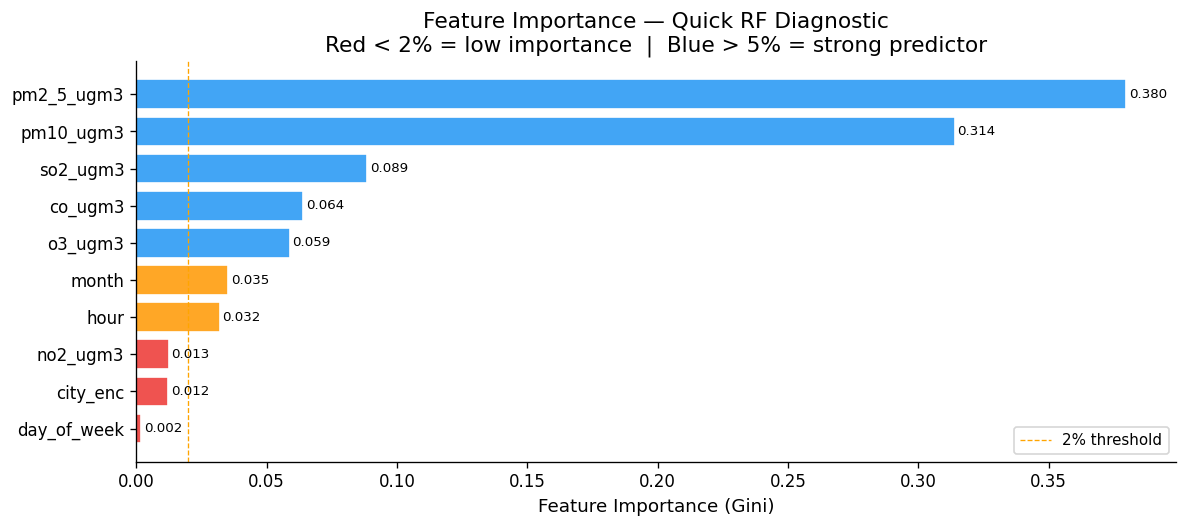

Low importance features (< 2%): ['day_of_week', 'city_enc', 'no2_ugm3']


In [ ]:
# Quick feature importance via lightweight Random Forest
try:
    from sklearn.ensemble import RandomForestClassifier

    sample_size = min(50000, len(X_train_bal))
    idx         = np.random.RandomState(42).choice(len(X_train_bal), sample_size, replace=False)

    rf = RandomForestClassifier(n_estimators=50, max_depth=8,
                                random_state=42, n_jobs=-1)
    rf.fit(X_train_bal[idx], y_train_bal[idx])

    imp_df = pd.DataFrame({'feature': ALL_FEATURES,
                           'importance': rf.feature_importances_})\
               .sort_values('importance', ascending=True)

    colors_imp = ['#EF5350' if v < 0.02 else '#FFA726' if v < 0.05 else '#42A5F5'
                  for v in imp_df['importance']]

    fig, ax = plt.subplots(figsize=(10, max(4, len(ALL_FEATURES) * 0.45)))
    bars    = ax.barh(imp_df['feature'], imp_df['importance'],
                      color=colors_imp, edgecolor='white')
    ax.axvline(0.02, color='orange', linestyle='--', linewidth=0.8, label='2% threshold')
    ax.set_xlabel('Feature Importance (Gini)')
    ax.set_title('Feature Importance - Quick RF Diagnostic\n'
                 'Red < 2% = low importance  |  Blue > 5% = strong predictor')
    for bar, val in zip(bars, imp_df['importance']):
        ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()

    low = imp_df[imp_df['importance'] < 0.02]['feature'].tolist()
    if low:
        print(f'Low importance features (< 2%): {low}')
    else:
        print('All features > 2% importance.')

except Exception as e:
    print(f'Feature importance skipped: {e}')

---
## Section 9 — Save Classification Datasets

In [ ]:
# Helper: numpy arrays -> DataFrame with feature names
def to_df(X, y, cols, int_to_cat):
    out = pd.DataFrame(X, columns=cols)
    out[TARGET_INT] = y
    out[TARGET_STR] = pd.Series(y).map(int_to_cat).values
    return out

train_unscaled_df = to_df(X_train_bal,    y_train_bal, ALL_FEATURES, INT_TO_CAT)
train_scaled_df   = to_df(X_train_scaled, y_train_bal, ALL_FEATURES, INT_TO_CAT)
test_unscaled_df  = to_df(X_test,         y_test,      ALL_FEATURES, INT_TO_CAT)
test_scaled_df    = to_df(X_test_scaled,  y_test,      ALL_FEATURES, INT_TO_CAT)

TRAIN_UNSCALED = os.path.join(OUTPUT_DIR, 'clf_train_unscaled.csv')
TRAIN_SCALED   = os.path.join(OUTPUT_DIR, 'clf_train_scaled.csv')
TEST_UNSCALED  = os.path.join(OUTPUT_DIR, 'clf_test_unscaled.csv')
TEST_SCALED    = os.path.join(OUTPUT_DIR, 'clf_test_scaled.csv')
LABEL_MAP_PATH = os.path.join(OUTPUT_DIR, 'label_map.json')
FEATURE_PATH   = os.path.join(OUTPUT_DIR, 'feature_list.txt')

train_unscaled_df.to_csv(TRAIN_UNSCALED, index=False)
train_scaled_df.to_csv(TRAIN_SCALED,     index=False)
test_unscaled_df.to_csv(TEST_UNSCALED,   index=False)
test_scaled_df.to_csv(TEST_SCALED,       index=False)

with open(LABEL_MAP_PATH, 'w') as f:
    json.dump({'int_to_category': INT_TO_CAT,
               'category_to_int': CAT_TO_INT,
               'city_encoding'  : city_encoding_map}, f, indent=2)

with open(FEATURE_PATH, 'w') as f:
    f.write('VAYU - Classification Feature List\n')
    f.write('=' * 50 + '\n\n')
    f.write(f'Target (string) : {TARGET_STR}\n')
    f.write(f'Target (int)    : {TARGET_INT}\n\n')
    f.write('Features:\n')
    for feat in ALL_FEATURES:
        f.write(f'  {feat}\n')
    f.write(f'\nTrain rows (balanced) : {len(train_unscaled_df):,}\n')
    f.write(f'Test rows             : {len(test_unscaled_df):,}\n')
    f.write(f'SMOTE applied         : {smote_applied}\n')
    f.write('\nFile guide:\n')
    f.write('  clf_train_scaled.csv   -> Logistic Regression, KNN, SVM\n')
    f.write('  clf_train_unscaled.csv -> Decision Trees, Random Forest\n')
    f.write('  clf_test_scaled.csv    -> test for Logistic Regression, KNN, SVM\n')
    f.write('  clf_test_unscaled.csv  -> test for Decision Trees, Random Forest\n')

print('SAVED:')
for path in [TRAIN_UNSCALED, TRAIN_SCALED, TEST_UNSCALED, TEST_SCALED]:
    mb = os.path.getsize(path) / 1024**2
    print(f'  {os.path.basename(path):<35} {mb:.1f} MB')
print(f'  label_map.json')
print(f'  feature_list.txt')
print()
print('=' * 60)
print('  STEP 4 COMPLETE')
print('=' * 60)
print(f'  Features          : {len(ALL_FEATURES)}')
print(f'  Classes           : {CAT_ORDER}')
print(f'  Train rows        : {len(train_unscaled_df):,}')
print(f'  Test rows         : {len(test_unscaled_df):,}')
print(f'  SMOTE applied     : {smote_applied}')
print()
print('  TO TRAIN - KNN / SVM / Logistic Regression (scaled):')
print('  train = pd.read_csv("data/cleaned/02_classification/clf_train_scaled.csv")')
print()
print('  TO TRAIN - Decision Trees / Random Forest (unscaled):')
print('  train = pd.read_csv("data/cleaned/02_classification/clf_train_unscaled.csv")')
print('=' * 60)

SAVED:
  clf_train_unscaled.csv              22.6 MB
  clf_train_scaled.csv                82.5 MB
  clf_test_unscaled.csv               5.7 MB
  clf_test_scaled.csv                 20.6 MB
  label_map.json
  feature_list.txt

  STEP 4 COMPLETE
  Features          : 10
  Classes           : ['Good', 'Satisfactory', 'Moderate', 'Poor', 'Very Poor', 'Severe']
  Train rows        : 417,847
  Test rows         : 104,462
  SMOTE applied     : False

  TO TRAIN — KNN / SVM / Logistic Regression (scaled):
  train = pd.read_csv("data/cleaned/02_classification/clf_train_scaled.csv")

  TO TRAIN — Decision Trees / Random Forest (unscaled):
  train = pd.read_csv("data/cleaned/02_classification/clf_train_unscaled.csv")
